<a href="https://colab.research.google.com/github/student-uzma/CSL701-CS10_Machine-Learning-Lab/blob/main/cs10_ML_Experiment_3_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

Name:- Uzma Choudhary Roll No:- CS10 Batch:-CS01

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
# TASK 1: SET UP PYTHON ENVIRONMENT

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# Upload the dataset in Google Colab
# --------------------------------------------------

from google.colab import files

uploaded = files.upload()

# Read the uploaded CSV file
df = pd.read_csv("cardekho_dataset.csv")

# --------------------------------------------------
# Display the dataset
# --------------------------------------------------

print("Dataset loaded successfully!")
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display number of rows and columns
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display information about the dataset
print("\nDataset Information:")
df.info()

# Display basic statistical information
print("\nStatistical Summary:")
display(df.describe())

Saving cardekho_dataset.csv to cardekho_dataset (1).csv
Dataset loaded successfully!

First 5 rows of the dataset:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Dataset Shape:
(15411, 14)

Column Names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power      

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
# ==========================================
# TASK 2: LOAD AND INSPECT THE DATASET
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Upload the dataset
# ------------------------------------------

from google.colab import files

uploaded = files.upload()

# Get the uploaded filename automatically
filename = list(uploaded.keys())[0]

# ------------------------------------------
# 2. Load the dataset
# ------------------------------------------

df = pd.read_csv(filename)

print("Dataset loaded successfully!")

# ------------------------------------------
# 3. Display first few records
# ------------------------------------------

print("\nFirst 5 records:")
display(df.head())

# ------------------------------------------
# 4. Number of rows and columns
# ------------------------------------------

rows, columns = df.shape

print("\nNumber of rows:", rows)
print("Number of columns:", columns)

# ------------------------------------------
# 5. Display column names
# ------------------------------------------

print("\nColumn names:")
print(df.columns.tolist())

# ------------------------------------------
# 6. Identify numerical attributes
# ------------------------------------------

numerical_attributes = df.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumerical attributes:")
print(numerical_attributes)

# ------------------------------------------
# 7. Identify categorical attributes
# ------------------------------------------

categorical_attributes = df.select_dtypes(
    include="object"
).columns.tolist()

print("\nCategorical attributes:")
print(categorical_attributes)

# ------------------------------------------
# 8. Separate selling_price as target
# ------------------------------------------

y = df["selling_price"]

print("\nTarget variable:")
print("selling_price")

print("\nFirst 5 target values:")
display(y.head())

# ------------------------------------------
# 9. Separate input features
# ------------------------------------------

X = df.drop("selling_price", axis=1)

print("\nInput features:")
display(X.head())

# ------------------------------------------
# 10. Dataset information
# ------------------------------------------

print("\nDataset Information:")
df.info()

Saving cardekho_dataset.csv to cardekho_dataset (4).csv
Dataset loaded successfully!

First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows: 15411
Number of columns: 14

Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target variable:
selling_price

First 5 target values:


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000



Input features:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# ==========================================
# TASK 3: CHECK AND HANDLE MISSING DATA
# ==========================================

# 1. Check missing values in every column

print("Missing values in each column:")
print(df.isnull().sum())


# 2. Check total number of missing values

total_missing = df.isnull().sum().sum()

print("\nTotal missing values in dataset:", total_missing)


# 3. Handle missing values

if total_missing > 0:
    print("\nMissing values are present.")
    print("Removing rows containing missing values...")

    # Remove rows with missing values
    df = df.dropna()

else:
    print("\nNo missing values found.")
    print("No rows were removed.")


# 4. Reset the index after removing rows

df = df.reset_index(drop=True)


# 5. Verify that no missing values remain

print("\nMissing values after preprocessing:")
print(df.isnull().sum())


# 6. Verify total missing values

remaining_missing = df.isnull().sum().sum()

print("\nTotal missing values after preprocessing:",
      remaining_missing)


# 7. Display final dataset shape

print("\nFinal dataset shape:")
print(df.shape)

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values in dataset: 0

No missing values found.
No rows were removed.

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values after preprocessing: 0

Final dataset shape:
(15411, 14)


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# ==========================================
# TASK 4: CREATE X AND y
# ==========================================

# Display current columns
print("Current columns:")
print(df.columns.tolist())


# ------------------------------------------
# 1. Create predictor matrix X
# ------------------------------------------

X = df.drop("selling_price", axis=1)


# ------------------------------------------
# 2. Create target vector y
# ------------------------------------------

y = df["selling_price"]


# ------------------------------------------
# 3. Convert X and y to NumPy arrays
# ------------------------------------------

X = X.to_numpy(dtype=float)
y = y.to_numpy(dtype=float)


# ------------------------------------------
# 4. Display results
# ------------------------------------------

print("\nPredictor matrix X created successfully!")
print("X shape:", X.shape)

print("\nTarget vector y created successfully!")
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
print(X[:5])

print("\nFirst 5 values of y:")
print(y[:5])

Current columns:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price', 'brand_BMW', 'brand_Bentley', 'brand_Datsun', 'brand_Ferrari', 'brand_Force', 'brand_Ford', 'brand_Honda', 'brand_Hyundai', 'brand_ISUZU', 'brand_Isuzu', 'brand_Jaguar', 'brand_Jeep', 'brand_Kia', 'brand_Land Rover', 'brand_Lexus', 'brand_MG', 'brand_Mahindra', 'brand_Maruti', 'brand_Maserati', 'brand_Mercedes-AMG', 'brand_Mercedes-Benz', 'brand_Mini', 'brand_Nissan', 'brand_Porsche', 'brand_Renault', 'brand_Rolls-Royce', 'brand_Skoda', 'brand_Tata', 'brand_Toyota', 'brand_Volkswagen', 'brand_Volvo', 'model_5', 'model_6', 'model_7', 'model_A4', 'model_A6', 'model_A8', 'model_Alto', 'model_Altroz', 'model_Alturas', 'model_Amaze', 'model_Aspire', 'model_Aura', 'model_Baleno', 'model_Bolero', 'model_C', 'model_C-Class', 'model_CLS', 'model_CR', 'model_CR-V', 'model_Camry', 'model_Carnival', 'model_Cayenne', 'model_Celerio', 'model_Ciaz', 'model_City', 'model_Civic', 'model_Compass', '

## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# ==========================================
# TASK 5: ENCODE CATEGORICAL VARIABLES
# ==========================================

# Reload original dataset
from google.colab import files
import pandas as pd
import numpy as np

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("Original dataset:")
display(df.head())


# ------------------------------------------
# 1. Identify categorical variables
# ------------------------------------------

categorical_variables = [
    "fuel_type",
    "seller_type",
    "transmission_type"
]

print("\nCategorical variables:")
print(categorical_variables)


# ------------------------------------------
# 2. Display unique categories
# ------------------------------------------

for column in categorical_variables:
    print("\n", column, "categories:")
    print(df[column].unique())


# ------------------------------------------
# 3. Convert categorical variables
#    into dummy/indicator variables
# ------------------------------------------

df_encoded = pd.get_dummies(
    df,
    columns=categorical_variables,
    drop_first=True,
    dtype=int
)


# ------------------------------------------
# 4. Remove unnecessary columns
# ------------------------------------------

# Remove index column and car_name
df_encoded = df_encoded.drop(
    ["Unnamed: 0", "car_name"],
    axis=1
)


# ------------------------------------------
# 5. Display transformed dataset
# ------------------------------------------

print("\nTransformed dataset:")
display(df_encoded.head())


# ------------------------------------------
# 6. Check data types
# ------------------------------------------

print("\nData types after encoding:")
print(df_encoded.dtypes)


# ------------------------------------------
# 7. Verify that all predictors are numerical
# ------------------------------------------

X = df_encoded.drop("selling_price", axis=1)

print("\nAre all predictor variables numerical?")

if all(np.issubdtype(dtype, np.number) for dtype in X.dtypes):
    print("Yes - all predictors are numerical.")
else:
    print("No - some predictors are still non-numerical.")


# ------------------------------------------
# 8. Display final dimensions
# ------------------------------------------

print("\nFinal dataset shape:")
print(df_encoded.shape)

Saving cardekho_dataset.csv to cardekho_dataset (5).csv
Original dataset:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Categorical variables:
['fuel_type', 'seller_type', 'transmission_type']

 fuel_type categories:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

 seller_type categories:
['Individual' 'Dealer' 'Trustmark Dealer']

 transmission_type categories:
['Manual' 'Automatic']

Transformed dataset:


,brand,model,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,Maruti,Alto,9,120000,19.70,796,46.30,5,120000,0,0,0,1,1,0,1
1,Hyundai,Grand,5,20000,18.90,1197,82.00,5,550000,0,0,0,1,1,0,1
2,Hyundai,i20,11,60000,17.00,1197,80.00,5,215000,0,0,0,1,1,0,1
3,Maruti,Alto,9,37000,20.92,998,67.10,5,226000,0,0,0,1,1,0,1
4,Ford,Ecosport,6,30000,22.77,1498,98.59,5,570000,1,0,0,0,0,0,1



Data types after encoding:
brand                            object
model                            object
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price                     int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_type_Manual          int64
dtype: object

Are all predictor variables numerical?
No - some predictors are still non-numerical.

Final dataset shape:
(15411, 16)


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
# ==========================================
# TASK 6: FEATURE ENGINEERING
# ==========================================

# Create a new feature called Car_Age
df_encoded["Car_Age"] = df_encoded["vehicle_age"]


# ------------------------------------------
# Display several values of Car_Age
# ------------------------------------------

print("First 10 values of Car_Age:")

display(
    df_encoded[["vehicle_age", "Car_Age"]].head(10)
)


# ------------------------------------------
# Check minimum and maximum age
# ------------------------------------------

print("\nMinimum Car Age:", df_encoded["Car_Age"].min())
print("Maximum Car Age:", df_encoded["Car_Age"].max())


# ------------------------------------------
# Check average age
# ------------------------------------------

print("Average Car Age:", df_encoded["Car_Age"].mean())


# ------------------------------------------
# Verify that ages are reasonable
# ------------------------------------------

if df_encoded["Car_Age"].min() >= 0:
    print("\nCar ages are reasonable: no negative ages found.")
else:
    print("\nWarning: Negative car ages found.")


# ------------------------------------------
# Check for missing values
# ------------------------------------------

print("\nMissing values in Car_Age:")
print(df_encoded["Car_Age"].isnull().sum())


# ------------------------------------------
# Display final dataset
# ------------------------------------------

print("\nDataset with Car_Age:")
display(df_encoded.head())

First 10 values of Car_Age:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Minimum Car Age: 0
Maximum Car Age: 29
Average Car Age: 6.0363376808772955

Car ages are reasonable: no negative ages found.

Missing values in Car_Age:
0

Dataset with Car_Age:


,brand,model,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual,Car_Age
0,Maruti,Alto,9,120000,19.70,796,46.30,5,120000,0,0,0,1,1,0,1,9
1,Hyundai,Grand,5,20000,18.90,1197,82.00,5,550000,0,0,0,1,1,0,1,5
2,Hyundai,i20,11,60000,17.00,1197,80.00,5,215000,0,0,0,1,1,0,1,11
3,Maruti,Alto,9,37000,20.92,998,67.10,5,226000,0,0,0,1,1,0,1,9
4,Ford,Ecosport,6,30000,22.77,1498,98.59,5,570000,1,0,0,0,0,0,1,6


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

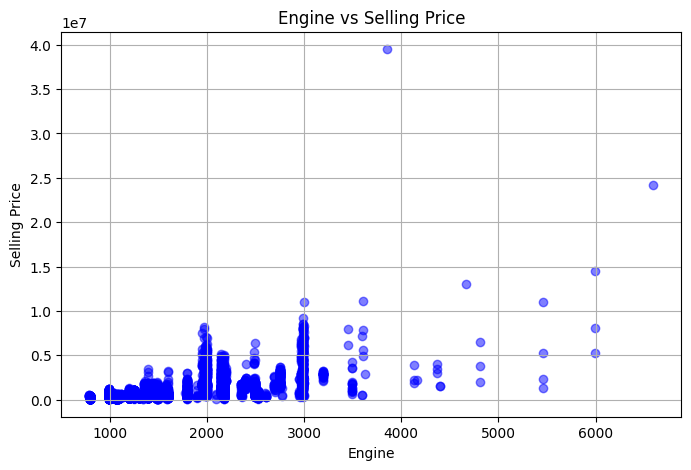

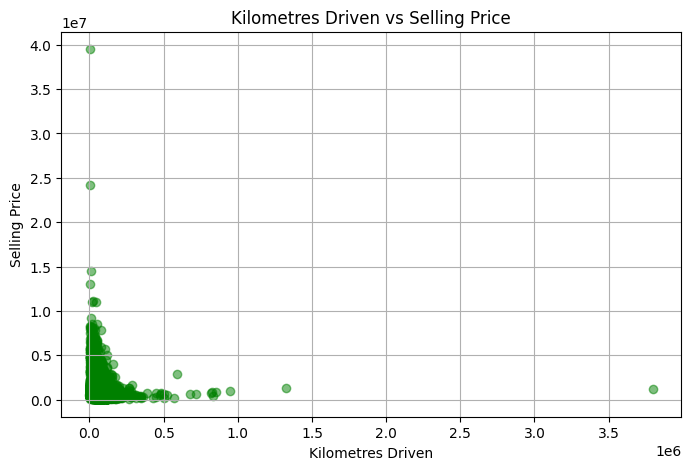

In [ ]:
# ==========================================
# TASK 7: EXPLORATORY DATA ANALYSIS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Load the original dataset
df_eda = pd.read_csv(filename)

# ------------------------------------------
# 1. Scatter plot: Present_Price vs
#    Selling_Price
# ------------------------------------------

# Your dataset does not contain Present_Price.
# Therefore, use engine vs selling_price
# as a meaningful numerical relationship.

plt.figure(figsize=(8, 5))

plt.scatter(
    df_eda["engine"],
    df_eda["selling_price"],
    alpha=0.5,
    color="blue"
)

plt.xlabel("Engine")
plt.ylabel("Selling Price")
plt.title("Engine vs Selling Price")

plt.grid(True)
plt.show()


# ------------------------------------------
# 2. Scatter plot: km_driven vs
#    Selling_Price
# ------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    df_eda["km_driven"],
    df_eda["selling_price"],
    alpha=0.5,
    color="green"
)

plt.xlabel("Kilometres Driven")
plt.ylabel("Selling Price")
plt.title("Kilometres Driven vs Selling Price")

plt.grid(True)
plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# ==========================================
# TASK 8: STANDARDIZE NUMERICAL FEATURES
# ==========================================

import pandas as pd
import numpy as np

# ------------------------------------------
# 1. Load the original dataset
# ------------------------------------------

df = pd.read_csv(filename)

print("Original dataset loaded.")
print(df.shape)


# ------------------------------------------
# 2. Remove unnecessary columns
# ------------------------------------------

# Unnamed: 0 = row index
# car_name = specific car name, not used

df = df.drop(["Unnamed: 0", "car_name"], axis=1)


# ------------------------------------------
# 3. Create Car_Age
# ------------------------------------------

# Your dataset already has vehicle_age,
# so use it to create Car_Age.

df["Car_Age"] = df["vehicle_age"]

# Remove duplicate age column
df = df.drop("vehicle_age", axis=1)


# ------------------------------------------
# 4. Separate target variable
# ------------------------------------------

y = df["selling_price"].to_numpy(dtype=float)

X_df = df.drop("selling_price", axis=1)


# ------------------------------------------
# 5. Convert ALL categorical variables
#    into dummy variables
# ------------------------------------------

categorical_columns = [
    "brand",
    "model",
    "seller_type",
    "fuel_type",
    "transmission_type"
]

X_df = pd.get_dummies(
    X_df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)


# ------------------------------------------
# 6. Convert X into NumPy array
# ------------------------------------------

X = X_df.to_numpy(dtype=float)


print("\nAll predictors are now numerical.")
print("Number of features:", X.shape[1])


# ------------------------------------------
# 7. Split into training and testing data
# ------------------------------------------

np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.80 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]


print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ------------------------------------------
# 8. Calculate mean and standard deviation
#    USING TRAINING DATA ONLY
# ------------------------------------------

train_mean = np.mean(X_train, axis=0)
train_std = np.std(X_train, axis=0)


# ------------------------------------------
# 9. Prevent division by zero
# ------------------------------------------

train_std[train_std == 0] = 1


# ------------------------------------------
# 10. Standardize training features
# ------------------------------------------

X_train_standardized = (
    X_train - train_mean
) / train_std


# ------------------------------------------
# 11. Standardize test features
#     using training mean and std
# ------------------------------------------

X_test_standardized = (
    X_test - train_mean
) / train_std


# ------------------------------------------
# 12. Display results
# ------------------------------------------

print("\nFirst 5 rows of standardized training data:")
print(X_train_standardized[:5])

print("\nFirst 5 rows of standardized test data:")
print(X_test_standardized[:5])


# ------------------------------------------
# 13. Verify standardization
# ------------------------------------------

print("\nMean of standardized training features:")
print(np.mean(X_train_standardized, axis=0)[:10])

print("\nStandard deviation of standardized training features:")
print(np.std(X_train_standardized, axis=0)[:10])


# ------------------------------------------
# 14. Verify target was NOT standardized
# ------------------------------------------

print("\nFirst 5 training target values:")
print(y_train[:5])

print("\nFirst 5 testing target values:")
print(y_test[:5])

Original dataset loaded.
(15411, 14)

All predictors are now numerical.
Number of features: 163

Training samples: 12328
Testing samples: 3083

First 5 rows of standardized training data:
[[ 3.17732278e-01  1.60198190e-01 -5.55760666e-01 -5.05726422e-01
  -4.02990451e-01  1.97683120e+00 -1.70687780e-01 -9.00681624e-03
  -1.06008483e-01 -9.00681624e-03 -9.00681624e-03 -2.31290140e-01
  -3.28838610e-01  2.04286832e+00  0.00000000e+00 -2.38355974e-02
  -6.25203550e-02 -4.68502241e-02 -4.59725732e-02 -6.25203550e-02
  -2.70292209e-02 -3.82390616e-02 -2.66761503e-01 -6.90222562e-01
  -9.00681624e-03 -9.00681624e-03 -1.50204461e-01 -3.37182047e-02
  -2.84924569e-02 -3.71601788e-02 -1.90335547e-01  0.00000000e+00
  -1.48786652e-01 -1.68409308e-01 -2.33423129e-01 -2.04098272e-01
  -3.24903559e-02 -8.62349302e-02 -3.71601788e-02 -4.93904955e-02
  -8.13256701e-02 -6.18631547e-02 -2.01431218e-02 -2.30900641e-01
  -9.00681624e-03 -9.00681624e-03 -1.57118513e-01 -6.75517089e-02
  -9.00681624e-03 -1

## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# ==========================================
# TASK 9: SPLIT THE DATASET
# ==========================================

import numpy as np

# ------------------------------------------
# 1. Set random seed
# ------------------------------------------

np.random.seed(42)


# ------------------------------------------
# 2. Get number of observations
# ------------------------------------------

n = len(X)

print("Total observations:", n)


# ------------------------------------------
# 3. Create random indices
# ------------------------------------------

indices = np.random.permutation(n)


# ------------------------------------------
# 4. Calculate 80% training size
# ------------------------------------------

train_size = int(0.80 * n)


# ------------------------------------------
# 5. Select training and testing indices
# ------------------------------------------

train_indices = indices[:train_size]
test_indices = indices[train_size:]


# ------------------------------------------
# 6. Create training and testing datasets
# ------------------------------------------

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]


# ------------------------------------------
# 7. Display number of observations
# ------------------------------------------

print("\nTraining observations:", len(X_train))
print("Testing observations:", len(X_test))


# ------------------------------------------
# 8. Display shapes
# ------------------------------------------

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Total observations: 15411

Training observations: 12328
Testing observations: 3083

X_train shape: (12328, 163)
X_test shape: (3083, 163)
y_train shape: (12328,)
y_test shape: (3083,)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
# ==========================================
# TASK 10: CONSTRUCT THE FEATURE MATRIX
# ==========================================

# ------------------------------------------
# 1. Create required matrices/vectors
# ------------------------------------------

Xtrain = X_train
ytrain = y_train

Xtest = X_test
ytest = y_test


# ------------------------------------------
# 2. Display shapes
# ------------------------------------------

print("Training feature matrix Xtrain:")
print("Shape:", Xtrain.shape)

print("\nTraining target vector ytrain:")
print("Shape:", ytrain.shape)

print("\nTesting feature matrix Xtest:")
print("Shape:", Xtest.shape)

print("\nTesting target vector ytest:")
print("Shape:", ytest.shape)


# ------------------------------------------
# 3. Number of rows
# ------------------------------------------

print("\nNumber of training rows:", Xtrain.shape[0])
print("Number of testing rows:", Xtest.shape[0])


# ------------------------------------------
# 4. Number of predictor columns
# ------------------------------------------

print("\nNumber of predictor columns:", Xtrain.shape[1])


# ------------------------------------------
# 5. Verify dimensions
# ------------------------------------------

print("\nDimension verification:")

print("Xtrain rows =", Xtrain.shape[0])
print("Xtrain columns =", Xtrain.shape[1])

print("ytrain rows =", ytrain.shape[0])

print("Xtest rows =", Xtest.shape[0])
print("Xtest columns =", Xtest.shape[1])

print("ytest rows =", ytest.shape[0])

Training feature matrix Xtrain:
Shape: (12328, 163)

Training target vector ytrain:
Shape: (12328,)

Testing feature matrix Xtest:
Shape: (3083, 163)

Testing target vector ytest:
Shape: (3083,)

Number of training rows: 12328
Number of testing rows: 3083

Number of predictor columns: 163

Dimension verification:
Xtrain rows = 12328
Xtrain columns = 163
ytrain rows = 12328
Xtest rows = 3083
Xtest columns = 163
ytest rows = 3083


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# ==========================================
# TASK 11: ADD BIAS / INTERCEPT TERM
# ==========================================

import numpy as np

# ------------------------------------------
# 1. Add a column of 1.0 to Xtrain
# ------------------------------------------

Xtrain_bias = np.c_[
    np.ones(Xtrain.shape[0]),
    Xtrain
]


# ------------------------------------------
# 2. Add a column of 1.0 to Xtest
# ------------------------------------------

Xtest_bias = np.c_[
    np.ones(Xtest.shape[0]),
    Xtest
]


# ------------------------------------------
# 3. Display dimensions
# ------------------------------------------

print("Original Xtrain shape:", Xtrain.shape)
print("New Xtrain shape:", Xtrain_bias.shape)

print("\nOriginal Xtest shape:", Xtest.shape)
print("New Xtest shape:", Xtest_bias.shape)


# ------------------------------------------
# 4. Verify the first column
# ------------------------------------------

print("\nFirst 5 rows of Xtrain_bias:")
print(Xtrain_bias[:5])

print("\nFirst column of Xtrain_bias:")
print(Xtrain_bias[:5, 0])


# ------------------------------------------
# 5. Verify all values in first column
# ------------------------------------------

print("\nAre all values in the bias column equal to 1?")
print(np.all(Xtrain_bias[:, 0] == 1.0))

Original Xtrain shape: (12328, 163)
New Xtrain shape: (12328, 164)

Original Xtest shape: (3083, 163)
New Xtest shape: (3083, 164)

First 5 rows of Xtrain_bias:
[[1.0000e+00 7.3000e+04 2.0360e+01 1.1970e+03 7.8900e+01 5.0000e+00
  1.2000e+01 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 1.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 0.0000e+00

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
# ==========================================
# TASK 12: IMPLEMENT OLS FUNCTION
# ==========================================

import numpy as np


# ------------------------------------------
# OLS Function
# ------------------------------------------

def ols(X, y):

    # Calculate X transpose
    XT = X.T

    # Calculate X^T X
    XTX = XT @ X

    # Calculate X^T y
    XTy = XT @ y

    # Calculate pseudoinverse of X^T X
    XTX_pinv = np.linalg.pinv(XTX)

    # Calculate regression coefficients
    beta = XTX_pinv @ XTy

    # Return coefficient vector
    return beta


# ------------------------------------------
# Calculate beta using training data
# ------------------------------------------

beta = ols(Xtrain_bias, ytrain)


# ------------------------------------------
# Display results
# ------------------------------------------

print("OLS regression coefficient vector:")
print(beta)

print("\nNumber of coefficients:", len(beta))

print("Coefficient vector shape:", beta.shape)

OLS regression coefficient vector:
[ 3.01558173e+06 -4.92839022e-01 -2.42229331e+03 -1.59595520e+02
  5.85219953e+03 -4.02675809e+04 -7.96529713e+04 -1.20094768e+06
  4.87907327e+06 -1.67316857e+06  1.69416593e+07 -8.27937261e+05
 -1.51643058e+06 -1.60333589e+06 -1.72702300e+06  1.06061343e-02
 -8.28691104e+05  2.09173875e+05  5.27624955e+03 -6.00330203e+05
  2.68099543e+05  1.70609386e+06 -7.48600536e+05 -1.54625526e+06
 -1.91373489e+06  1.27323896e+06  4.73699729e+05  2.79754345e+05
 -3.62620985e+05 -1.27719873e+06  1.38063775e+06 -1.58046705e+06
  2.64344025e-02 -1.37120639e+06 -1.75492766e+06 -1.21509040e+06
 -1.34481883e+06  1.11960338e+06  9.49706397e+05  2.62598551e+06
  1.70797924e+06 -1.32505720e+06 -9.82679385e+05  2.78883542e+05
 -8.62170281e+04 -4.12139853e+05  1.10769406e+06 -5.25353580e+05
 -6.51423645e+05 -2.43939756e+05 -1.31553530e+05 -2.66439710e+04
  4.73699733e+05 -1.52209176e+06 -1.83848465e+05  1.56023978e+04
  2.81410260e+05 -6.57677131e+04  3.53780884e+05  3.452

## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# ==========================================
# TASK 13: CHECK MATRIX SINGULARITY
# ==========================================

import numpy as np

# ------------------------------------------
# 1. Calculate X^T X
# ------------------------------------------

XTX = Xtrain_bias.T @ Xtrain_bias

print("Shape of X^T X:")
print(XTX.shape)


# ------------------------------------------
# 2. Calculate determinant
# ------------------------------------------

det_XTX = np.linalg.det(XTX)

print("\nDeterminant of X^T X:")
print(det_XTX)


# ------------------------------------------
# 3. Check whether matrix is singular
# ------------------------------------------

if np.isclose(det_XTX, 0):
    print("\nResult: X^T X is singular or nearly singular.")
else:
    print("\nResult: X^T X is not singular.")


# ------------------------------------------
# 4. Check matrix rank
# ------------------------------------------

rank = np.linalg.matrix_rank(XTX)

number_of_columns = XTX.shape[0]

print("\nMatrix rank:", rank)
print("Number of columns:", number_of_columns)


# ------------------------------------------
# 5. Additional check
# ------------------------------------------

if rank < number_of_columns:
    print("\nThe matrix is rank deficient.")
    print("There is redundancy or multicollinearity among predictors.")
else:
    print("\nThe matrix has full rank.")

Shape of X^T X:
(164, 164)

Determinant of X^T X:
0.0

Result: X^T X is singular or nearly singular.

Matrix rank: 117
Number of columns: 164

The matrix is rank deficient.
There is redundancy or multicollinearity among predictors.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# ==========================================
# TASK 14: TRAIN THE REGRESSION MODEL
# ==========================================

import numpy as np


# ------------------------------------------
# 1. OLS function
# ------------------------------------------

def ols(X, y):

    XTX = X.T @ X
    XTy = X.T @ y

    # Pseudoinverse handles singular matrices
    beta = np.linalg.pinv(XTX) @ XTy

    return beta


# ------------------------------------------
# 2. Train the regression model
# ------------------------------------------

beta = ols(Xtrain_bias, ytrain)


# ------------------------------------------
# 3. Display intercept
# ------------------------------------------

beta_0 = beta[0]

print("Intercept (β0):")
print(beta_0)


# ------------------------------------------
# 4. Get feature names
# ------------------------------------------

feature_names = X_df.columns.tolist()


# ------------------------------------------
# 5. Display coefficients
# ------------------------------------------

print("\nRegression Coefficients:")
print("------------------------------------------")

print(f"Intercept (β0): {beta[0]:.4f}")

for feature, coefficient in zip(feature_names, beta[1:]):
    print(f"{feature}: {coefficient:.4f}")

Intercept (β0):
3015581.7259275913

Regression Coefficients:
------------------------------------------
Intercept (β0): 3015581.7259
km_driven: -0.4928
mileage: -2422.2933
engine: -159.5955
max_power: 5852.1995
seats: -40267.5809
Car_Age: -79652.9713
brand_BMW: -1200947.6787
brand_Bentley: 4879073.2679
brand_Datsun: -1673168.5685
brand_Ferrari: 16941659.2847
brand_Force: -827937.2609
brand_Ford: -1516430.5751
brand_Honda: -1603335.8925
brand_Hyundai: -1727022.9973
brand_ISUZU: 0.0106
brand_Isuzu: -828691.1042
brand_Jaguar: 209173.8751
brand_Jeep: 5276.2495
brand_Kia: -600330.2028
brand_Land Rover: 268099.5427
brand_Lexus: 1706093.8572
brand_MG: -748600.5363
brand_Mahindra: -1546255.2634
brand_Maruti: -1913734.8888
brand_Maserati: 1273238.9591
brand_Mercedes-AMG: 473699.7290
brand_Mercedes-Benz: 279754.3449
brand_Mini: -362620.9848
brand_Nissan: -1277198.7258
brand_Porsche: 1380637.7548
brand_Renault: -1580467.0516
brand_Rolls-Royce: 0.0264
brand_Skoda: -1371206.3906
brand_Tata: -175492

## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
# ==========================================
# TASK 15: INTERPRET REGRESSION COEFFICIENTS
# ==========================================

import pandas as pd
import numpy as np


# ------------------------------------------
# 1. Create coefficient table
# ------------------------------------------

feature_names = X_df.columns.tolist()

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta[1:]
})


# ------------------------------------------
# 2. Identify positive and negative
#    coefficients
# ------------------------------------------

coefficient_table["Direction"] = np.where(
    coefficient_table["Coefficient"] > 0,
    "Positive",
    "Negative"
)


# ------------------------------------------
# 3. Calculate absolute coefficient
# ------------------------------------------

coefficient_table["Absolute_Coefficient"] = (
    np.abs(coefficient_table["Coefficient"])
)


# ------------------------------------------
# 4. Sort by influence
# ------------------------------------------

coefficient_table = coefficient_table.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)


# ------------------------------------------
# 5. Display all coefficients
# ------------------------------------------

print("Regression Coefficient Interpretation:")
display(coefficient_table)


# ------------------------------------------
# 6. Display positive coefficients
# ------------------------------------------

print("\nPositive coefficients:")
display(
    coefficient_table[
        coefficient_table["Coefficient"] > 0
    ].head(10)
)


# ------------------------------------------
# 7. Display negative coefficients
# ------------------------------------------

print("\nNegative coefficients:")
display(
    coefficient_table[
        coefficient_table["Coefficient"] < 0
    ].head(10)
)


# ------------------------------------------
# 8. Features with greatest influence
# ------------------------------------------

print("\nTop 10 features by absolute coefficient:")
display(
    coefficient_table[
        ["Feature", "Coefficient", "Direction"]
    ].head(10)
)

Regression Coefficient Interpretation:


,Feature,Coefficient,Direction,Absolute_Coefficient
9,brand_Ferrari,1.694166e+07,Positive,1.694166e+07
86,model_GTC4Lusso,1.694166e+07,Positive,1.694166e+07
7,brand_Bentley,4.879073e+06,Positive,4.879073e+06
64,model_Continental,4.879073e+06,Positive,4.879073e+06
143,model_XC,3.188003e+06,Positive,3.188003e+06
...,...,...,...,...
0,km_driven,-4.928390e-01,Negative,4.928390e-01
31,brand_Rolls-Royce,2.643440e-02,Positive,2.643440e-02
14,brand_ISUZU,1.060613e-02,Positive,1.060613e-02
111,model_Quattroporte,3.813312e-06,Positive,3.813312e-06



Positive coefficients:


,Feature,Coefficient,Direction,Absolute_Coefficient
9,brand_Ferrari,1.694166e+07,Positive,1.694166e+07
86,model_GTC4Lusso,1.694166e+07,Positive,1.694166e+07
7,brand_Bentley,4.879073e+06,Positive,4.879073e+06
64,model_Continental,4.879073e+06,Positive,4.879073e+06
143,model_XC,3.188003e+06,Positive,3.188003e+06
141,model_X4,3.159537e+06,Positive,3.159537e+06
84,model_GLS,2.721679e+06,Positive,2.721679e+06
38,model_6,2.625986e+06,Positive,2.625986e+06
142,model_X5,2.122204e+06,Positive,2.122204e+06
112,model_RX,2.068357e+06,Positive,2.068357e+06



Negative coefficients:


,Feature,Coefficient,Direction,Absolute_Coefficient
144,model_XC60,-2.444587e+06,Negative,2.444587e+06
23,brand_Maruti,-1.913735e+06,Negative,1.913735e+06
33,brand_Tata,-1.754928e+06,Negative,1.754928e+06
13,brand_Hyundai,-1.727023e+06,Negative,1.727023e+06
8,brand_Datsun,-1.673169e+06,Negative,1.673169e+06
63,model_Compass,-1.628029e+06,Negative,1.628029e+06
12,brand_Honda,-1.603336e+06,Negative,1.603336e+06
30,brand_Renault,-1.580467e+06,Negative,1.580467e+06
22,brand_Mahindra,-1.546255e+06,Negative,1.546255e+06
52,model_C-Class,-1.522092e+06,Negative,1.522092e+06



Top 10 features by absolute coefficient:


,Feature,Coefficient,Direction
9,brand_Ferrari,1.694166e+07,Positive
86,model_GTC4Lusso,1.694166e+07,Positive
7,brand_Bentley,4.879073e+06,Positive
64,model_Continental,4.879073e+06,Positive
143,model_XC,3.188003e+06,Positive
141,model_X4,3.159537e+06,Positive
84,model_GLS,2.721679e+06,Positive
38,model_6,2.625986e+06,Positive
144,model_XC60,-2.444587e+06,Negative
142,model_X5,2.122204e+06,Positive


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# ==========================================
# TASK 16: PREDICT SELLING PRICES
# ==========================================

import numpy as np
import pandas as pd


# ------------------------------------------
# 1. Predict selling prices
# ------------------------------------------

y_pred = Xtest_bias @ beta


# ------------------------------------------
# 2. Display predicted values
# ------------------------------------------

print("First 10 predicted selling prices:")
print(y_pred[:10])


# ------------------------------------------
# 3. Compare actual and predicted prices
# ------------------------------------------

comparison = pd.DataFrame({
    "Actual Selling Price": ytest,
    "Predicted Selling Price": y_pred
})


# Display first 10 comparisons
print("\nActual vs Predicted Selling Prices:")
display(comparison.head(10))

First 10 predicted selling prices:
[2244807.71237576 1434608.59887607  447787.40520888  428785.93110086
  798456.23239242 -255898.62398387  704570.22556291  -38714.07575088
  334877.71335658 1097785.93321204]

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,4450000.0,2.244808e+06
1,1290000.0,1.434609e+06
2,485000.0,4.477874e+05
3,400000.0,4.287859e+05
4,800000.0,7.984562e+05
5,150000.0,-2.558986e+05
6,650000.0,7.045702e+05
7,325000.0,-3.871408e+04
8,300000.0,3.348777e+05
9,925000.0,1.097786e+06


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# ==========================================
# TASK 17: CALCULATE PREDICTION ERRORS AND RSS
# ==========================================

import numpy as np
import pandas as pd


# ------------------------------------------
# 1. Calculate residuals
# ------------------------------------------

residuals = ytest - y_pred


# ------------------------------------------
# 2. Calculate squared residuals
# ------------------------------------------

squared_residuals = residuals ** 2


# ------------------------------------------
# 3. Calculate RSS
# ------------------------------------------

RSS = np.sum(squared_residuals)


# ------------------------------------------
# 4. Display RSS
# ------------------------------------------

print("Residual Sum of Squares (RSS):")
print(RSS)


# ------------------------------------------
# 5. Display sample prediction errors
# ------------------------------------------

error_table = pd.DataFrame({
    "Actual Price": ytest,
    "Predicted Price": y_pred,
    "Residual": residuals,
    "Squared Residual": squared_residuals
})

print("\nFirst 10 prediction errors:")
display(error_table.head(10))

Residual Sum of Squares (RSS):
969077595632925.2

First 10 prediction errors:


,Actual Price,Predicted Price,Residual,Squared Residual
0,4450000.0,2.244808e+06,2.205192e+06,4.862873e+12
1,1290000.0,1.434609e+06,-1.446086e+05,2.091165e+10
2,485000.0,4.477874e+05,3.721259e+04,1.384777e+09
3,400000.0,4.287859e+05,-2.878593e+04,8.286298e+08
4,800000.0,7.984562e+05,1.543768e+03,2.383218e+06
5,150000.0,-2.558986e+05,4.058986e+05,1.647537e+11
6,650000.0,7.045702e+05,-5.457023e+04,2.977910e+09
7,325000.0,-3.871408e+04,3.637141e+05,1.322879e+11
8,300000.0,3.348777e+05,-3.487771e+04,1.216455e+09
9,925000.0,1.097786e+06,-1.727859e+05,2.985498e+10


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# ==========================================
# TASK 18: CALCULATE AND INTERPRET R²
# ==========================================

import numpy as np


# ------------------------------------------
# 1. Calculate mean of actual test prices
# ------------------------------------------

ytest_mean = np.mean(ytest)


# ------------------------------------------
# 2. Calculate Total Sum of Squares (TSS)
# ------------------------------------------

TSS = np.sum(
    (ytest - ytest_mean) ** 2
)


# ------------------------------------------
# 3. Calculate R²
# ------------------------------------------

R2 = 1 - (RSS / TSS)


# ------------------------------------------
# 4. Display TSS and R²
# ------------------------------------------

print("Total Sum of Squares (TSS):")
print(TSS)

print("\nResidual Sum of Squares (RSS):")
print(RSS)

print("\nR² Score:")
print(R2)


# ------------------------------------------
# 5. Interpret R²
# ------------------------------------------

print("\nInterpretation:")

if R2 >= 0:
    print(
        f"The model explains approximately {R2 * 100:.2f}% "
        "of the variation in used-car selling prices."
    )
else:
    print(
        "The R² value is negative, indicating that the model "
        "performs worse than simply predicting the mean selling price."
    )

Total Sum of Squares (TSS):
2407385049859876.5

Residual Sum of Squares (RSS):
969077595632925.2

R² Score:
0.5974563372447084

Interpretation:
The model explains approximately 59.75% of the variation in used-car selling prices.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


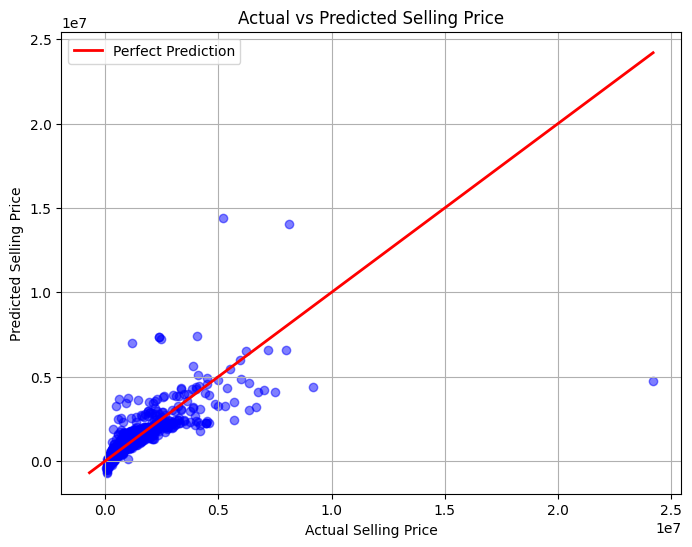

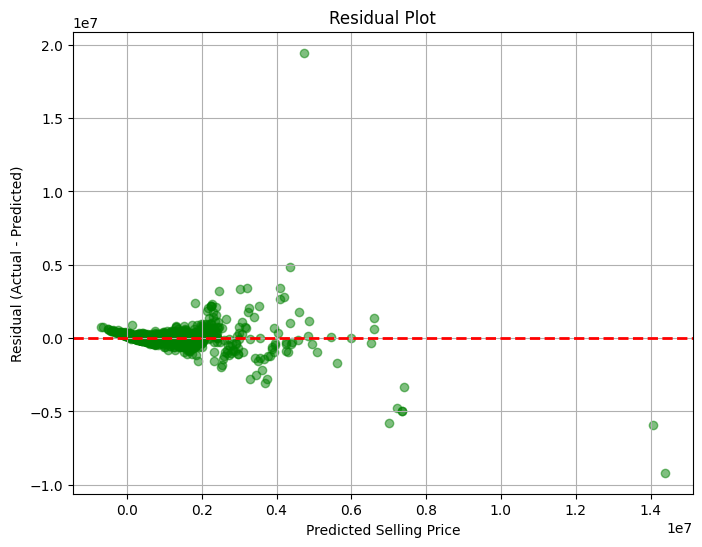

10 observations with the largest prediction errors:


,Actual,Predicted,Residual,Absolute_Error
2796,24200000.0,4.736265e+06,1.946373e+07,1.946373e+07
2050,5200000.0,1.438014e+07,-9.180140e+06,9.180140e+06
1552,8100000.0,1.405725e+07,-5.957247e+06,5.957247e+06
2120,1200000.0,6.998231e+06,-5.798231e+06,5.798231e+06
2439,2400000.0,7.344442e+06,-4.944442e+06,4.944442e+06
867,2400000.0,7.342547e+06,-4.942547e+06,4.942547e+06
2362,9200000.0,4.363091e+06,4.836909e+06,4.836909e+06
1243,2450000.0,7.216490e+06,-4.766490e+06,4.766490e+06
1092,6645000.0,3.219955e+06,3.425045e+06,3.425045e+06
841,7500000.0,4.096585e+06,3.403415e+06,3.403415e+06



Mean Absolute Error (MAE):
186685.86860982628

Maximum absolute prediction error:
19463734.883994143


In [ ]:
# ==========================================
# TASK 19: VISUALIZE AND ANALYZE
# MODEL PERFORMANCE
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ------------------------------------------
# 1. Actual vs Predicted Selling Price
# ------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    ytest,
    y_pred,
    alpha=0.5,
    color="blue"
)

# Perfect prediction line
min_value = min(ytest.min(), y_pred.min())
max_value = max(ytest.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------
# 2. Residual Plot
# ------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5,
    color="green"
)

# Zero-error reference line
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)

plt.show()


# ------------------------------------------
# 3. Identify large prediction errors
# ------------------------------------------

error_table = pd.DataFrame({
    "Actual": ytest,
    "Predicted": y_pred,
    "Residual": residuals
})

error_table["Absolute_Error"] = np.abs(
    error_table["Residual"]
)


# Sort by largest absolute error
largest_errors = error_table.sort_values(
    by="Absolute_Error",
    ascending=False
)


print("10 observations with the largest prediction errors:")
display(largest_errors.head(10))


# ------------------------------------------
# 4. Calculate average absolute error
# ------------------------------------------

MAE = np.mean(np.abs(residuals))

print("\nMean Absolute Error (MAE):")
print(MAE)


# ------------------------------------------
# 5. Calculate maximum error
# ------------------------------------------

max_error = np.max(np.abs(residuals))

print("\nMaximum absolute prediction error:")
print(max_error)

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


##Advantages of Multiple Linear Regression
Simple and interpretable
The effect of each predictor can be examined through its regression coefficient.
Works with multiple features
Several characteristics such as vehicle age, mileage, engine size, maximum power, brand, fuel type, and transmission can be considered simultaneously.
Computationally efficient
Linear regression is relatively fast to train, especially when compared with more complex machine-learning models.
Provides quantitative relationships
The coefficients show the direction and magnitude of the relationship between predictors and selling price.
Useful baseline model
Multiple Linear Regression provides a good baseline against which more advanced prediction models can be compared.




##Limitations of Multiple Linear Regression
Assumes a linear relationship
Used-car prices may have nonlinear relationships with mileage, age, engine size, and other variables.
Sensitive to outliers
Very expensive or unusual vehicles can strongly affect the regression coefficients.
Multicollinearity
Variables such as brand and model can contain overlapping information. This was evident in this dataset because X
T
X became singular.
Categorical variables require encoding
Variables such as brand, model, fuel type, seller type, and transmission must be converted into numerical dummy variables.
Some important factors may be missing
Car condition, accident history, service history, location, number of previous owners, and optional features may influence the selling price but may not be fully represented in the dataset.
Prediction errors remain
The RSS, R², and residual analysis from Tasks 17–19 show that the model cannot explain every variation in used-car prices.
